# Stock Market Analysis & Prediction using LSTM

**Stocks Analyzed:** Apple, Google, Microsoft, Amazon, Tesla, Nvidia, Meta.
**Data Source:** Yahoo Finance via yfinance
**Time Period:** Last 10 years
**Prediction Target:** Apple(AAPL) Closing Price using LSTM

## Table of Contents


## Key Questions we are asking;

1. What was the change in price of the stock over time?

2. What was the daily return of the stock on average?
3. What was the moving average of the various stocks?
4. What was the correlation between different stocks'?
5. How much value do we put at risk by investing in a particular stock?
6. How can we attempt to predict future stock behavior? (Predicting the closing price stock price of APPLE inc using LSTM)



<a id='1'></a>
## ⚙️ 1. Environment Setup

Install and import all required libraries.

In [1]:
# Core libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np 
import yfinance as yf
from datetime import datetime, timedelta

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('darkgrid')
PALETTE = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

# Machine Learning libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")








✅ All libraries imported successfully!
TensorFlow version: 2.15.0
NumPy version: 1.26.4
Pandas version: 3.0.1


In [2]:
import sys, platform
print("Python:", sys.version)
print("OS:", platform.version())

Python: 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
OS: 10.0.26200


In [3]:
import cpuinfo
print(cpuinfo.get_cpu_info()['flags'])

['3dnow', '3dnowprefetch', 'abm', 'acpi', 'adx', 'aes', 'apic', 'avx', 'avx2', 'bmi1', 'bmi2', 'clflush', 'clflushopt', 'clwb', 'cmov', 'cx16', 'cx8', 'de', 'dts', 'erms', 'est', 'f16c', 'fma', 'fpu', 'fxsr', 'gfni', 'ht', 'hypervisor', 'ia64', 'intel_pt', 'invpcid', 'lahf_lm', 'mca', 'mce', 'mmx', 'monitor', 'movbe', 'msr', 'mtrr', 'osxsave', 'pae', 'pat', 'pbe', 'pcid', 'pclmulqdq', 'pdcm', 'pge', 'pni', 'popcnt', 'pse', 'pse36', 'rdpid', 'rdrnd', 'rdseed', 'sep', 'serial', 'sha', 'smap', 'smep', 'ss', 'sse', 'sse2', 'sse4_1', 'sse4_2', 'ssse3', 'tm', 'tm2', 'tsc', 'tscdeadline', 'umip', 'vaes', 'vme', 'vpclmulqdq', 'x2apic', 'xsave', 'xtpr']


In [2]:
# Config

TICKERS = {
    'GOOGL': 'Google',
    'AAPL': 'Apple',
    'MSFT': 'Microsoft',
    'AMZN': 'Amazon',
    'META': 'Meta',
    'TSLA': 'Tesla',
    'NVDA': 'NVIDIA'
}

END = datetime.now()
START = datetime(END.year - 10, END.month, END.day)

# Download & tag
frames = {}
for ticker, name in TICKERS.items():
    df = yf.download(ticker, start=START, end=END, progress=False, auto_adjust=True)
    df.columns = df.columns.get_level_values(0) # Flatten multi-index columns
    df['company_name'] = name.upper() # Add company name column
    frames[ticker] = df
    
# Combine & clean
df = pd.concat(frames.values(), axis=0).sort_index()
df.index.name = 'date'
print(df.tail(10))

Price            Close        High         Low        Open     Volume  \
date                                                                    
2026-03-20  301.000000  306.000000  298.269989  305.459991   44364100   
2026-03-20  172.699997  178.259995  171.720001  178.000000  241323500   
2026-03-20  367.959991  379.890015  364.459991  379.850006   78628600   
2026-03-23  210.139999  212.800003  209.509995  209.779999   43926097   
2026-03-23  380.850006  385.329987  372.730011  373.084991   72583482   
2026-03-23  302.059998  305.970001  300.929993  302.109985   27375734   
2026-03-23  604.059998  608.640015  599.010010  605.786987   13258580   
2026-03-23  251.490005  254.559998  250.279999  253.990005   37465587   
2026-03-23  383.000000  387.209991  381.679993  383.994995   28357488   
2026-03-23  175.639999  178.369995  174.759995  177.250000  176073078   

Price      company_name  
date                     
2026-03-20       GOOGLE  
2026-03-20       NVIDIA  
2026-03-20        T

In [3]:
df.head()

Price,Close,High,Low,Open,Volume,company_name
date,,,,,,
2016-03-24,37.432625,37.567508,37.217405,37.252117,31116000,GOOGLE
2016-03-24,23.932192,24.063551,23.755537,23.886896,104532000,APPLE
2016-03-24,0.844075,0.845543,0.832569,0.835262,244956000,NVIDIA
2016-03-24,47.698776,47.804365,47.276430,47.373218,19950000,MICROSOFT
2016-03-24,15.183333,15.259333,14.333333,14.385333,74413500,TESLA


<a id='3'></a>
### 📊 Q1 — What was the change in price of the stock over time?

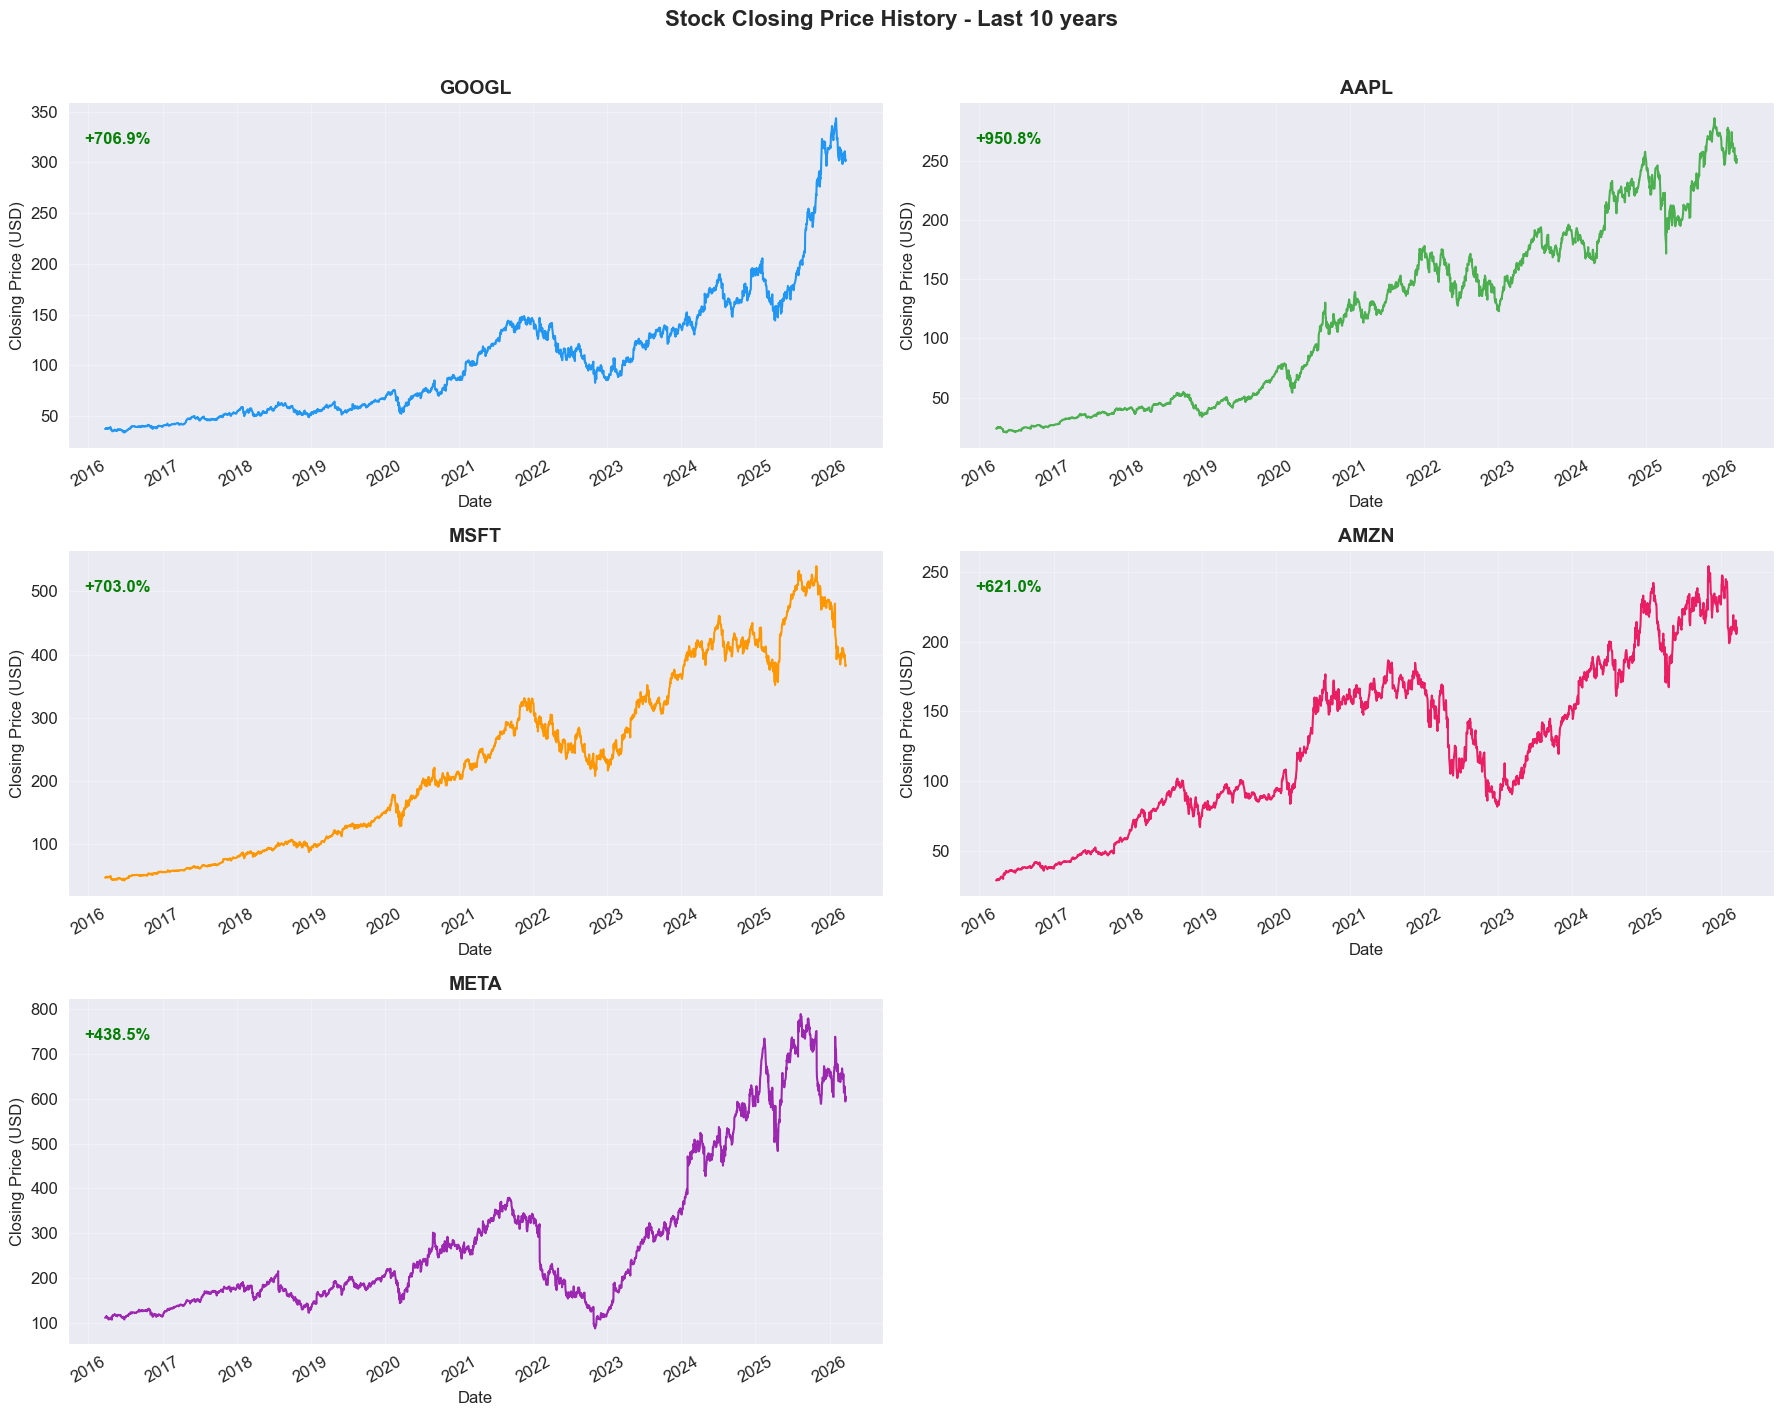

In [4]:
# -- Plot 1: Individual closing price history--

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle('Stock Closing Price History - Last 10 years', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, (ticker, color) in enumerate(zip(TICKERS, PALETTE)):
    df = frames[ticker]
    axes[i].plot(df.index, df['Close'], color=color, linewidth=1.5, label=ticker)
    axes[i].set_title(ticker, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Closing Price (USD)')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=30)
    
    # Annotate total return
    start_p = df['Close'].iloc[0]
    end_p = df['Close'].iloc[-1]
    pct_chg = ((end_p - start_p) / start_p) * 100
    axes[i].annotate(
        f'+{pct_chg:.1f}%' if pct_chg >= 0 else f'{pct_chg:.1f}%',
        xy=(0.02, 0.88), xycoords='axes fraction', 
        fontsize=12, fontweight='bold',
        color='green' if pct_chg >= 0 else 'red'
    )
    
fig.delaxes(axes[5]) # Remove empty subplot
plt.tight_layout()
plt.savefig('closing_price_history.png', dpi=300, bbox_inches='tight')
plt.show()
    

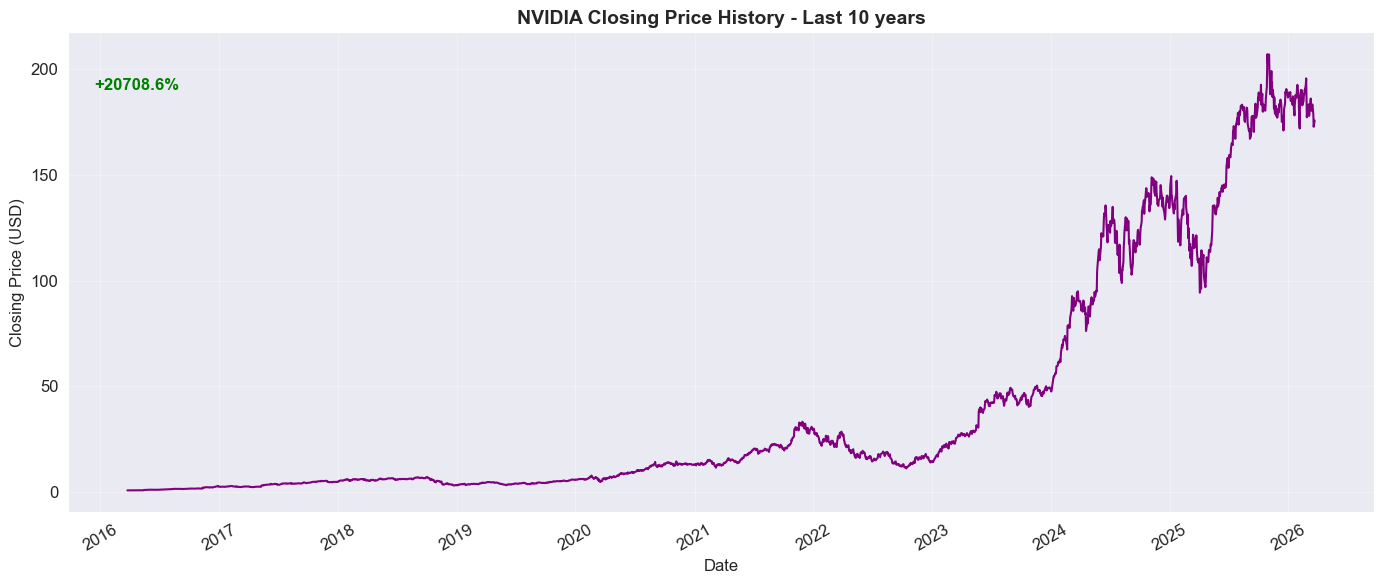

In [6]:
# -- Plot: NVIDIA Closing Price History --

df_nvda = frames['NVDA']

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_nvda.index, df_nvda['Close'], color='purple', linewidth=1.5, label='NVDA')
ax.set_title('NVIDIA Closing Price History - Last 10 years', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=30)

# Annotate total return
start_p = df_nvda['Close'].iloc[0]
end_p = df_nvda['Close'].iloc[-1]
pct_chg = ((end_p - start_p) / start_p) * 100
ax.annotate(
    f'+{pct_chg:.1f}%' if pct_chg >= 0 else f'{pct_chg:.1f}%',
    xy=(0.02, 0.88), xycoords='axes fraction', 
    fontsize=12, fontweight='bold',
    color='green' if pct_chg >= 0 else 'red'
)

plt.tight_layout()
plt.savefig('nvidia_closing_price_history.png', dpi=300, bbox_inches='tight')
plt.show()

* All the companys took a deep in 2023 and 2025, the stock closing prices went down. What exactly happened?

**Key Questions to ask**
1. What are the macro and micro economic situations affecting the globe or US?
2. Are there other  factors that could have contributed to that?
3. Could it be AI?

Is there a correlation between all this? or was it random or by chance?


In [6]:
closing_prices = pd.DataFrame(
    {ticker: frames[ticker]['Close'] for ticker in TICKERS}
)
print(closing_prices.head())

                GOOGL       AAPL       MSFT       AMZN        META       TSLA  \
Date                                                                            
2016-03-24  37.432625  23.932192  47.698776  29.147499  112.169754  15.183333   
2016-03-28  37.355263  23.823484  47.109257  28.993500  112.804771  15.350667   
2016-03-29  37.980595  24.387415  48.138741  29.693001  115.235695  15.342000   
2016-03-30  38.102085  24.813202  48.437897  29.934500  113.806908  15.126000   
2016-03-31  37.832317  24.684105  48.596272  29.681999  113.211578  15.318000   

                NVDA  
Date                  
2016-03-24  0.844075  
2016-03-28  0.852643  
2016-03-29  0.866351  
2016-03-30  0.875409  
2016-03-31  0.872227  


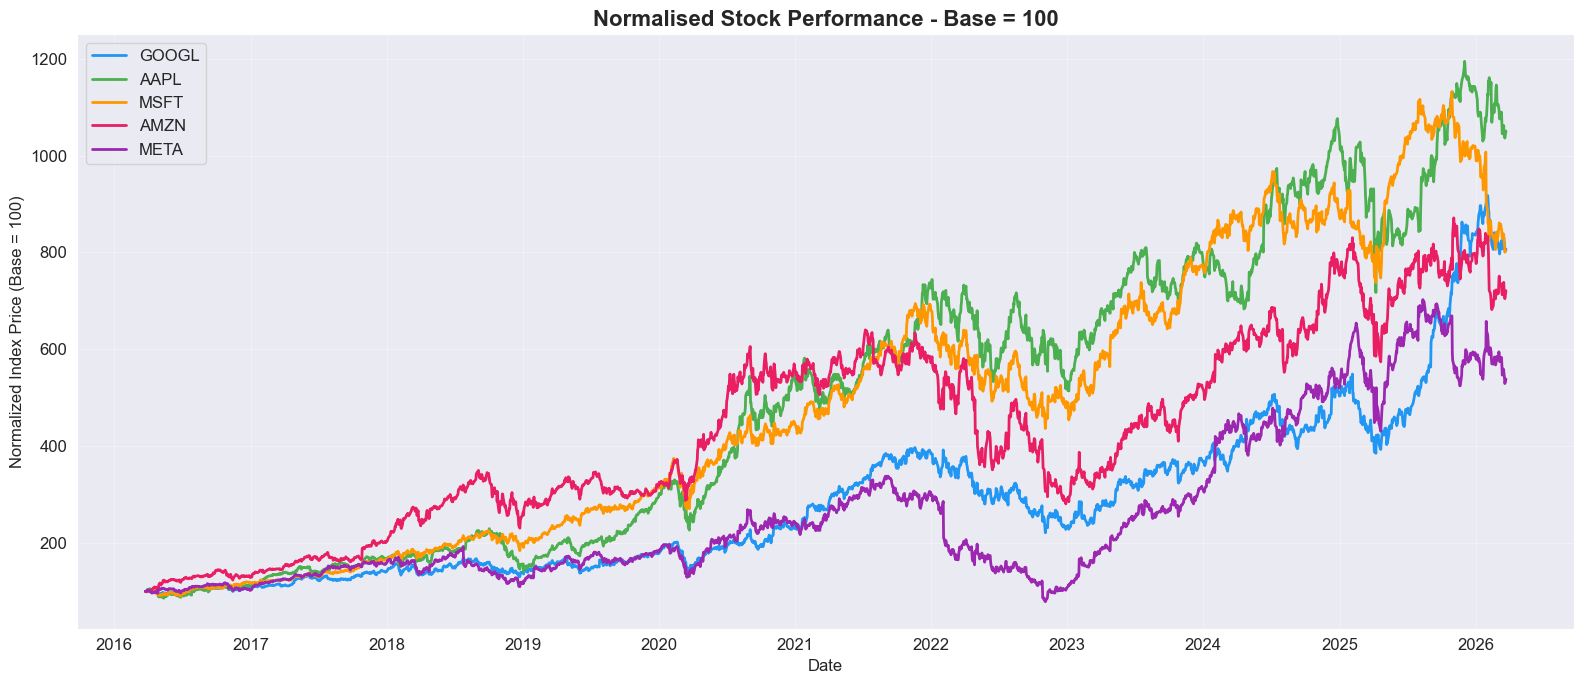


📊 Stock Performance Summary (Last 10 years) 📊



,Start Price ($),End Price ($),Max Price ($),Min Price ($),Total Return (%)
GOOGL,37.43,302.06,343.45,33.78,706.94
AAPL,23.93,251.49,285.92,20.58,950.84
MSFT,47.70,383.00,539.83,42.91,702.96
AMZN,29.15,210.14,254.00,28.99,620.95
META,112.17,604.06,788.15,88.22,438.52
TSLA,15.18,380.85,489.88,11.93,2408.34
NVDA,0.84,175.64,207.02,0.84,20708.58


In [8]:
# Plot 2: Normalized closing price history(Base = 100)
normalized = closing_prices / closing_prices.iloc[0] * 100

plt.figure(figsize=(16, 7))
for ticker, color in zip(TICKERS, PALETTE):
    plt.plot(normalized.index, normalized[ticker], label=ticker, color=color, linewidth=2)

plt.title('Normalised Stock Performance - Base = 100', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Normalized Index Price (Base = 100)')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('normalized_stock_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# -- Summary table

summary = pd.DataFrame({
    'Start Price ($)': closing_prices.iloc[0],
    'End Price ($)': closing_prices.iloc[-1],
    'Max Price ($)': closing_prices.max(),
    'Min Price ($)': closing_prices.min(),
    'Total Return (%)': ((closing_prices.iloc[-1] - closing_prices.iloc[0]) / closing_prices.iloc[0]) * 100
}).round(2)

print('\n📊 Stock Performance Summary (Last 10 years) 📊\n')
summary



Across all the companies, the start price and the end price has significantly increased for  500% return over the 10 years.
Though NVIDIA has the lowest start price and end price, it's stock price grew by the largest percentage over the last 10 years. This can be attributed to factors like the emergency and growth of AI  ang gaming. Meta had the highest starting price and end price with a minimal percentage change in terms of retuns compared to the other tech companies.

Will this bull/ bubble market burst like the housing and mortgage market in 2008?

<a id='4'></a>
###  📉 Q2 — What was the daily return of the stock on average?

In [7]:
# -- Compute daily % returns --
daily_returns = closing_prices.pct_change().dropna() * 100

print("\n📈 Daily Percentage Returns (First 5 rows) 📈\n")
stats = daily_returns.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats.columns = ['Mean (%)', 'Std Dev (%)', 'Min (%)', '25th %', 'Median (%)', '75th %', 'Max (%)']
stats = stats.round(4)
print(stats)        


📈 Daily Percentage Returns (First 5 rows) 📈

       Mean (%)  Std Dev (%)  Min (%)  25th %  Median (%)  75th %  Max (%)
GOOGL    0.0996       1.8107 -11.6341 -0.7648      0.1275  1.0047  10.2244
AAPL     0.1103       1.8228 -12.8647 -0.7088      0.1001  0.9889  15.3289
MSFT     0.0973       1.6919 -14.7391 -0.6665      0.1024  0.9608  14.2169
AMZN     0.0995       2.0453 -14.0494 -0.8844      0.1166  1.1385  13.5359
META     0.0965       2.4130 -26.3901 -0.9545      0.0910  1.2290  23.2824
TSLA     0.1971       3.7175 -21.0628 -1.7381      0.1244  1.9780  22.6900
NVDA     0.2615       3.1376 -18.7559 -1.3190      0.2807  1.8544  29.8067


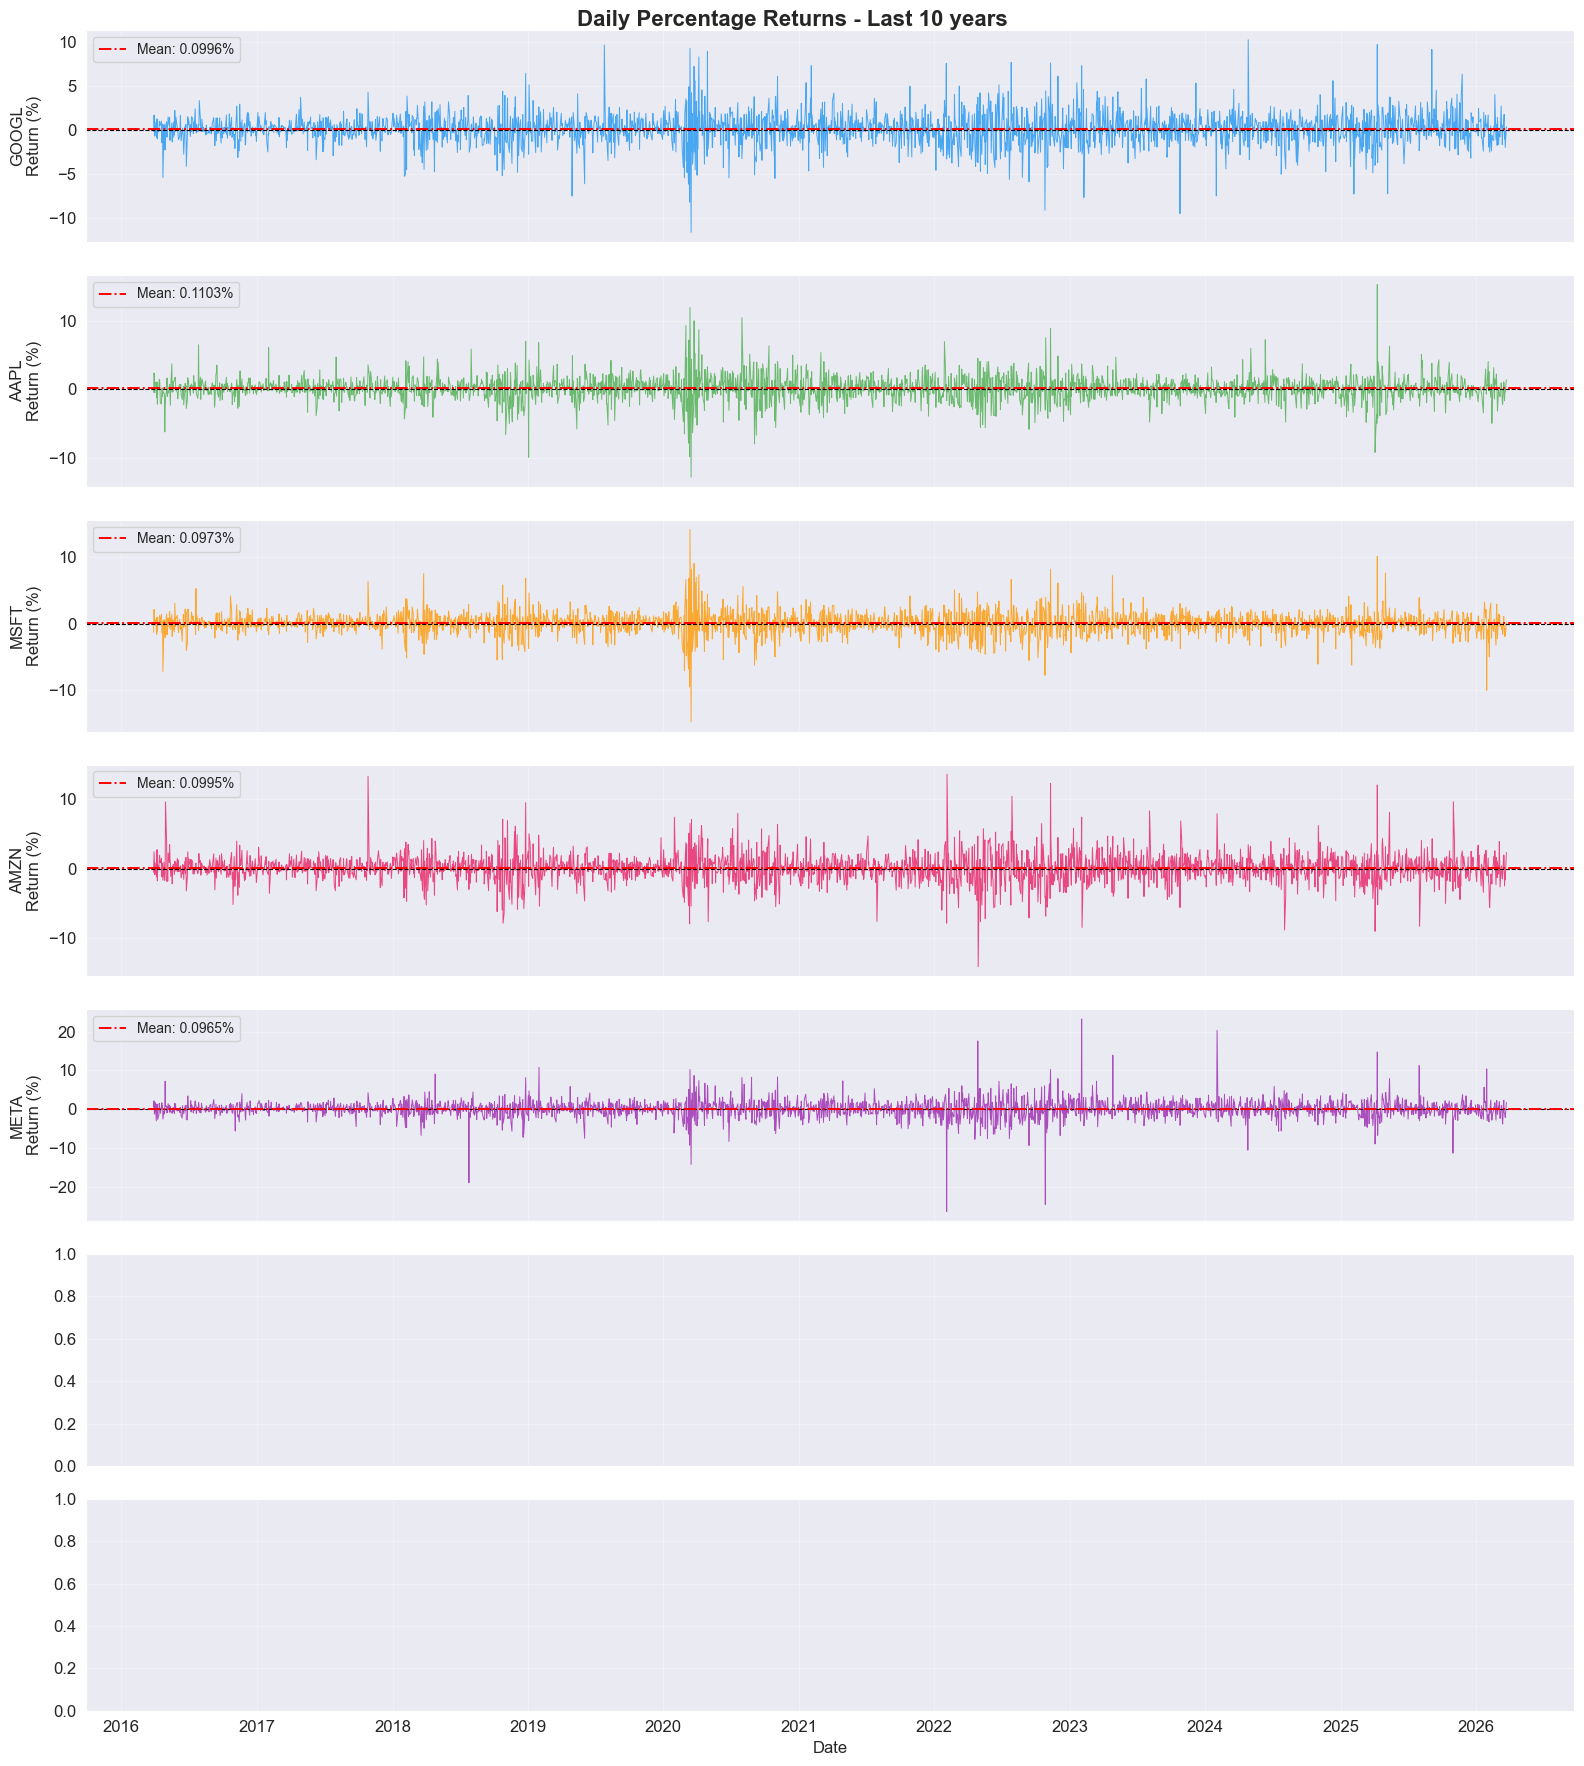

In [11]:
# Plot 3: Daily returns time-series
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(16, 18), sharex=True)
fig.suptitle('Daily Percentage Returns - Last 10 years', fontsize=16, fontweight='bold')

for ax, ticker, color in zip(axes, TICKERS, PALETTE):
    ret = daily_returns[ticker]
    ax.plot(ret.index, ret, color=color, linewidth=0.7, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8,  linestyle='--')
    ax.axhline(ret.mean(), color='red',   linewidth=1.4,  linestyle='-.',
               label=f'Mean: {ret.mean():.4f}%')
    ax.set_ylabel(f'{ticker}\nReturn (%)')
    ax.legend(loc='upper left', fontsize=10)
    
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('daily_percentage_returns.png', dpi=300, bbox_inches='tight')
plt.show()

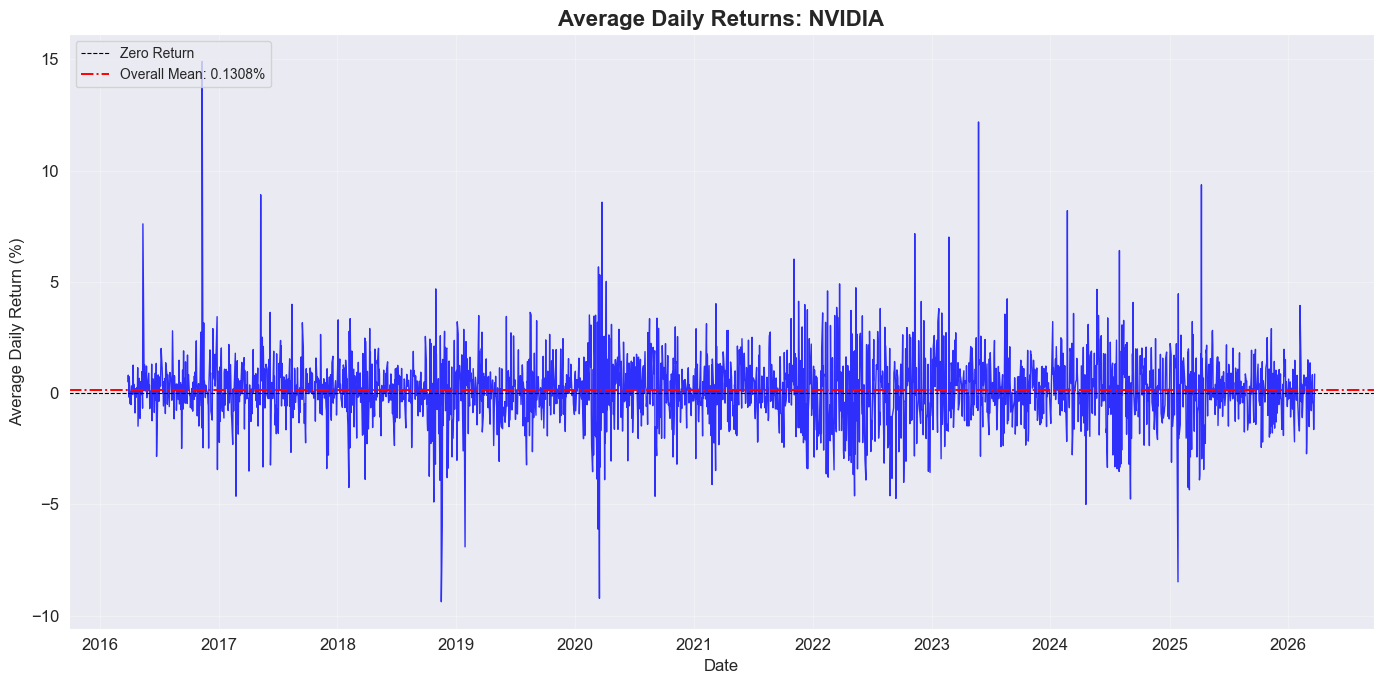

In [ ]:
# Calculate average daily returns for NVDA 
avg_daily_returns = (daily_returns['NVDA'] / 2)

# Plot the time series
plt.figure(figsize=(14, 7))
plt.plot(avg_daily_returns.index, avg_daily_returns, color='blue', linewidth=1.0, alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--', label='Zero Return')
plt.axhline(avg_daily_returns.mean(), color='red', linewidth=1.4, linestyle='-.', 
           label=f'Overall Mean: {avg_daily_returns.mean():.4f}%')
plt.title('Average Daily Returns: NVIDIA', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Daily Return (%)')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('avg_daily_returns_nvda.png', dpi=300, bbox_inches='tight')
plt.show()

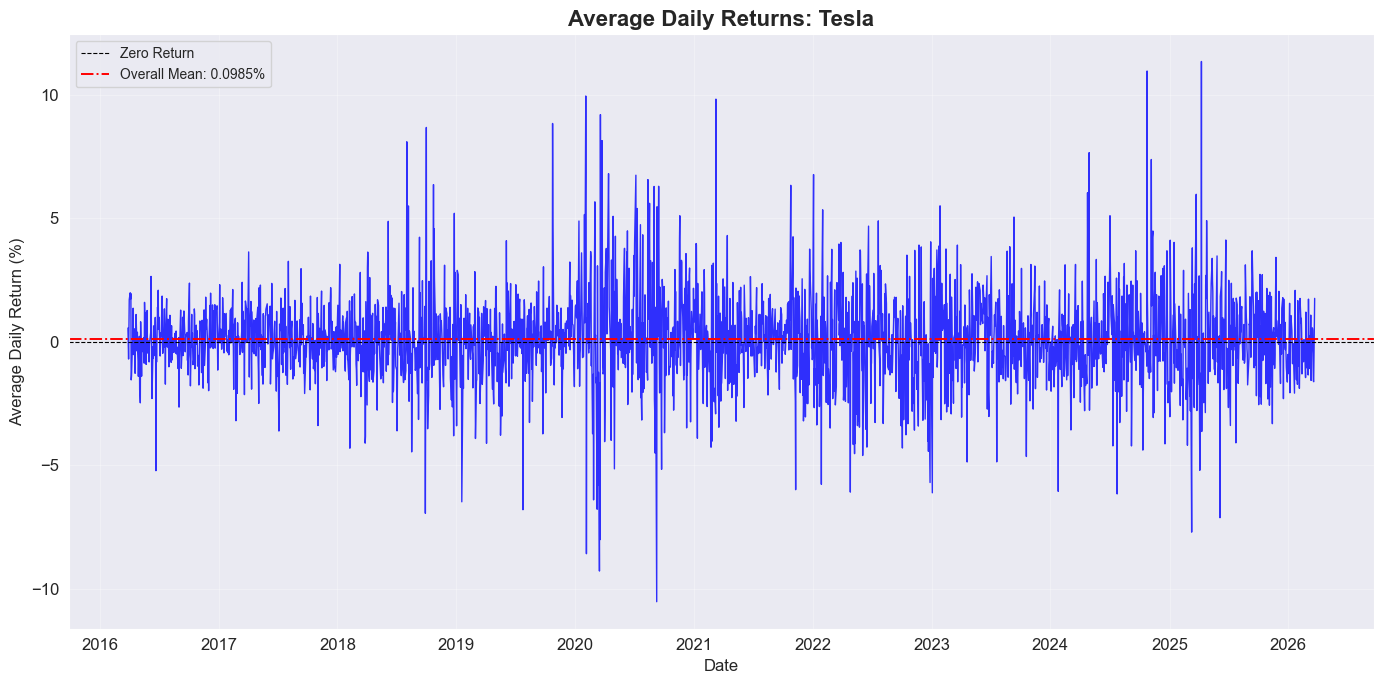

In [16]:
# Calculate average daily returns for TSLA 
avg_daily_returns = (daily_returns['TSLA'] / 2)

# Plot the time series
plt.figure(figsize=(14, 7))
plt.plot(avg_daily_returns.index, avg_daily_returns, color='blue', linewidth=1.0, alpha=0.8)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--', label='Zero Return')
plt.axhline(avg_daily_returns.mean(), color='red', linewidth=1.4, linestyle='-.', 
           label=f'Overall Mean: {avg_daily_returns.mean():.4f}%')
plt.title('Average Daily Returns: Tesla', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Daily Return (%)')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('avg_daily_returns_tsla.png', dpi=300, bbox_inches='tight')
plt.show()

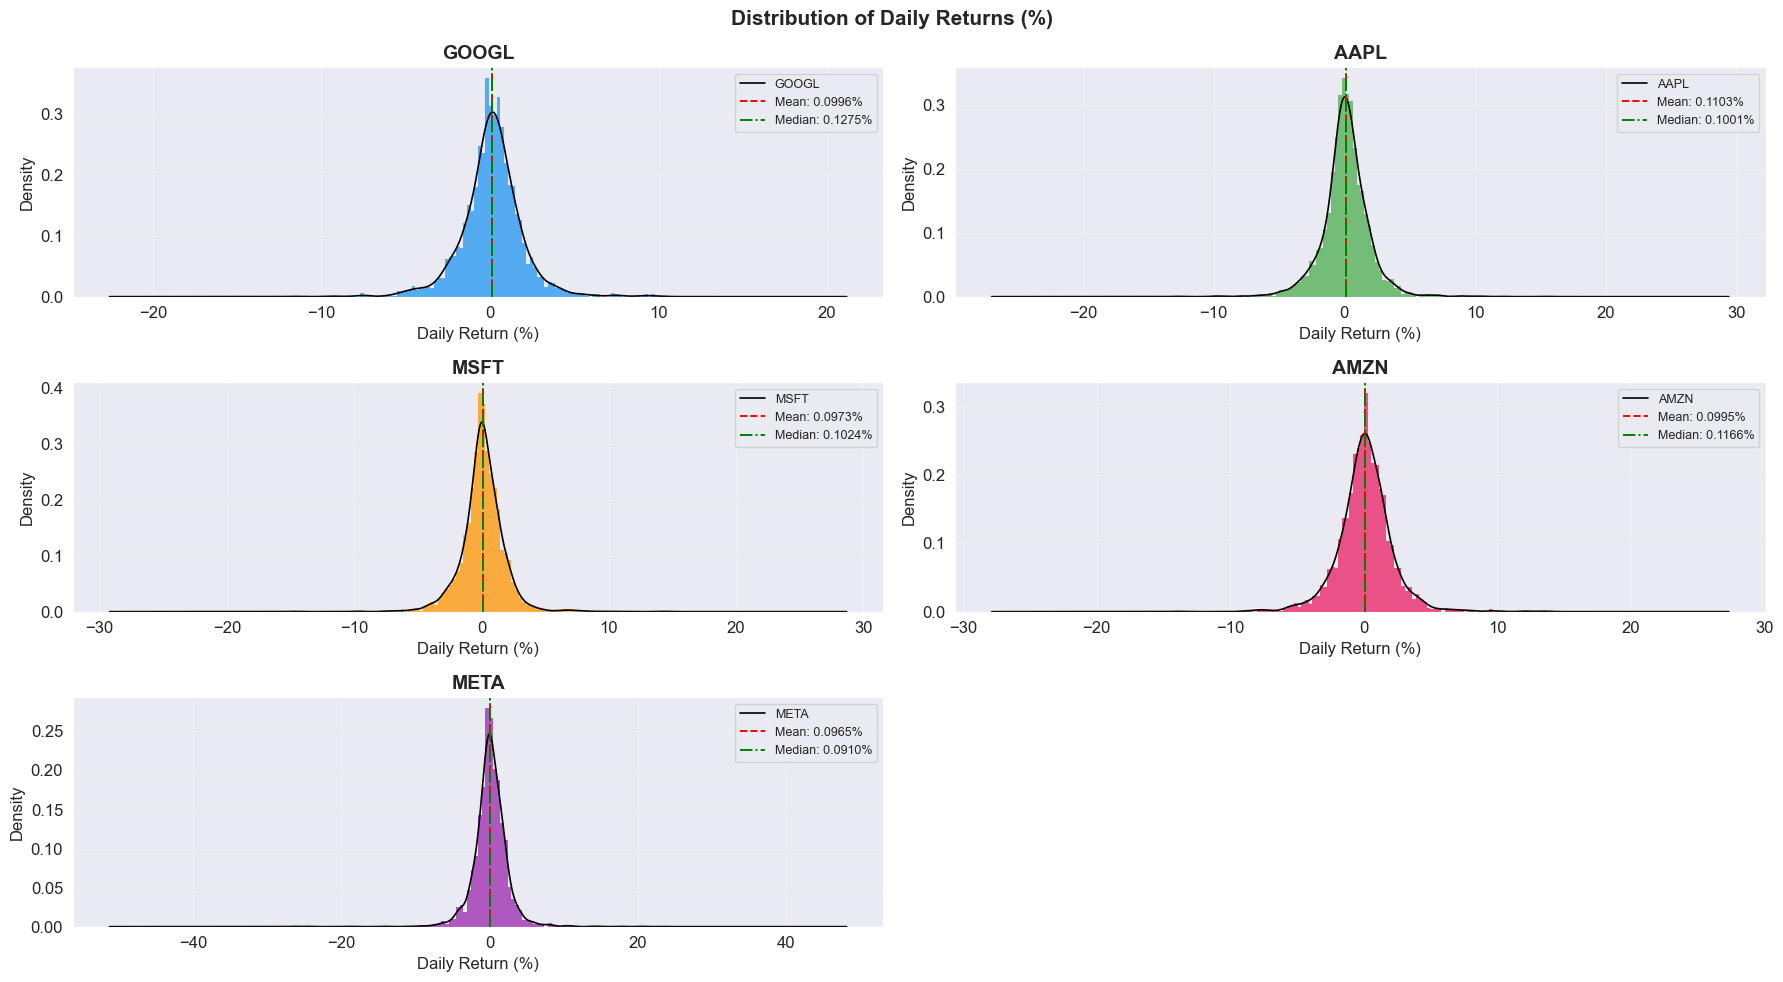

In [17]:
# Plot 4: Distribution histograms
fig, axes = plt.subplots(3, 2, figsize=(18, 10))
fig.suptitle('Distribution of Daily Returns (%)', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, (ticker, color) in enumerate(zip(TICKERS, PALETTE)):
    ret = daily_returns[ticker]
    axes[i].hist(ret, bins=100, color=color, alpha=0.75, edgecolor='none', density=True)
    ret.plot(kind='kde', color='black', linewidth=1.2, ax=axes[i])
    axes[i].axvline(ret.mean(), color='red', linestyle='--', linewidth=1.4, label=f'Mean: {ret.mean():.4f}%')
    axes[i].axvline(ret.median(), color='green', linestyle='-.', linewidth=1.4, label=f'Median: {ret.median():.4f}%')
    axes[i].set_title(ticker, fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Daily Return (%)')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)
    
fig.delaxes(axes[5]) # Remove empty subplot
plt.tight_layout()
plt.savefig('daily_returns_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

<a id='5'></a>
### 📐 Q3 — What was the moving average of the various stocks?

In [18]:
# -- Compute MA-10, MA-20, MA-50--

MA_WINDOWS = [10, 20, 50]

for ticker in TICKERS:
    for w in MA_WINDOWS:
        frames[ticker][f'MA_{w}'] = frames[ticker]['Close'].rolling(window=w).mean()    

print("\n✅ Moving averages (MA-10, MA-20, MA-50) computed and added to each DataFrame!")


✅ Moving averages (MA-10, MA-20, MA-50) computed and added to each DataFrame!


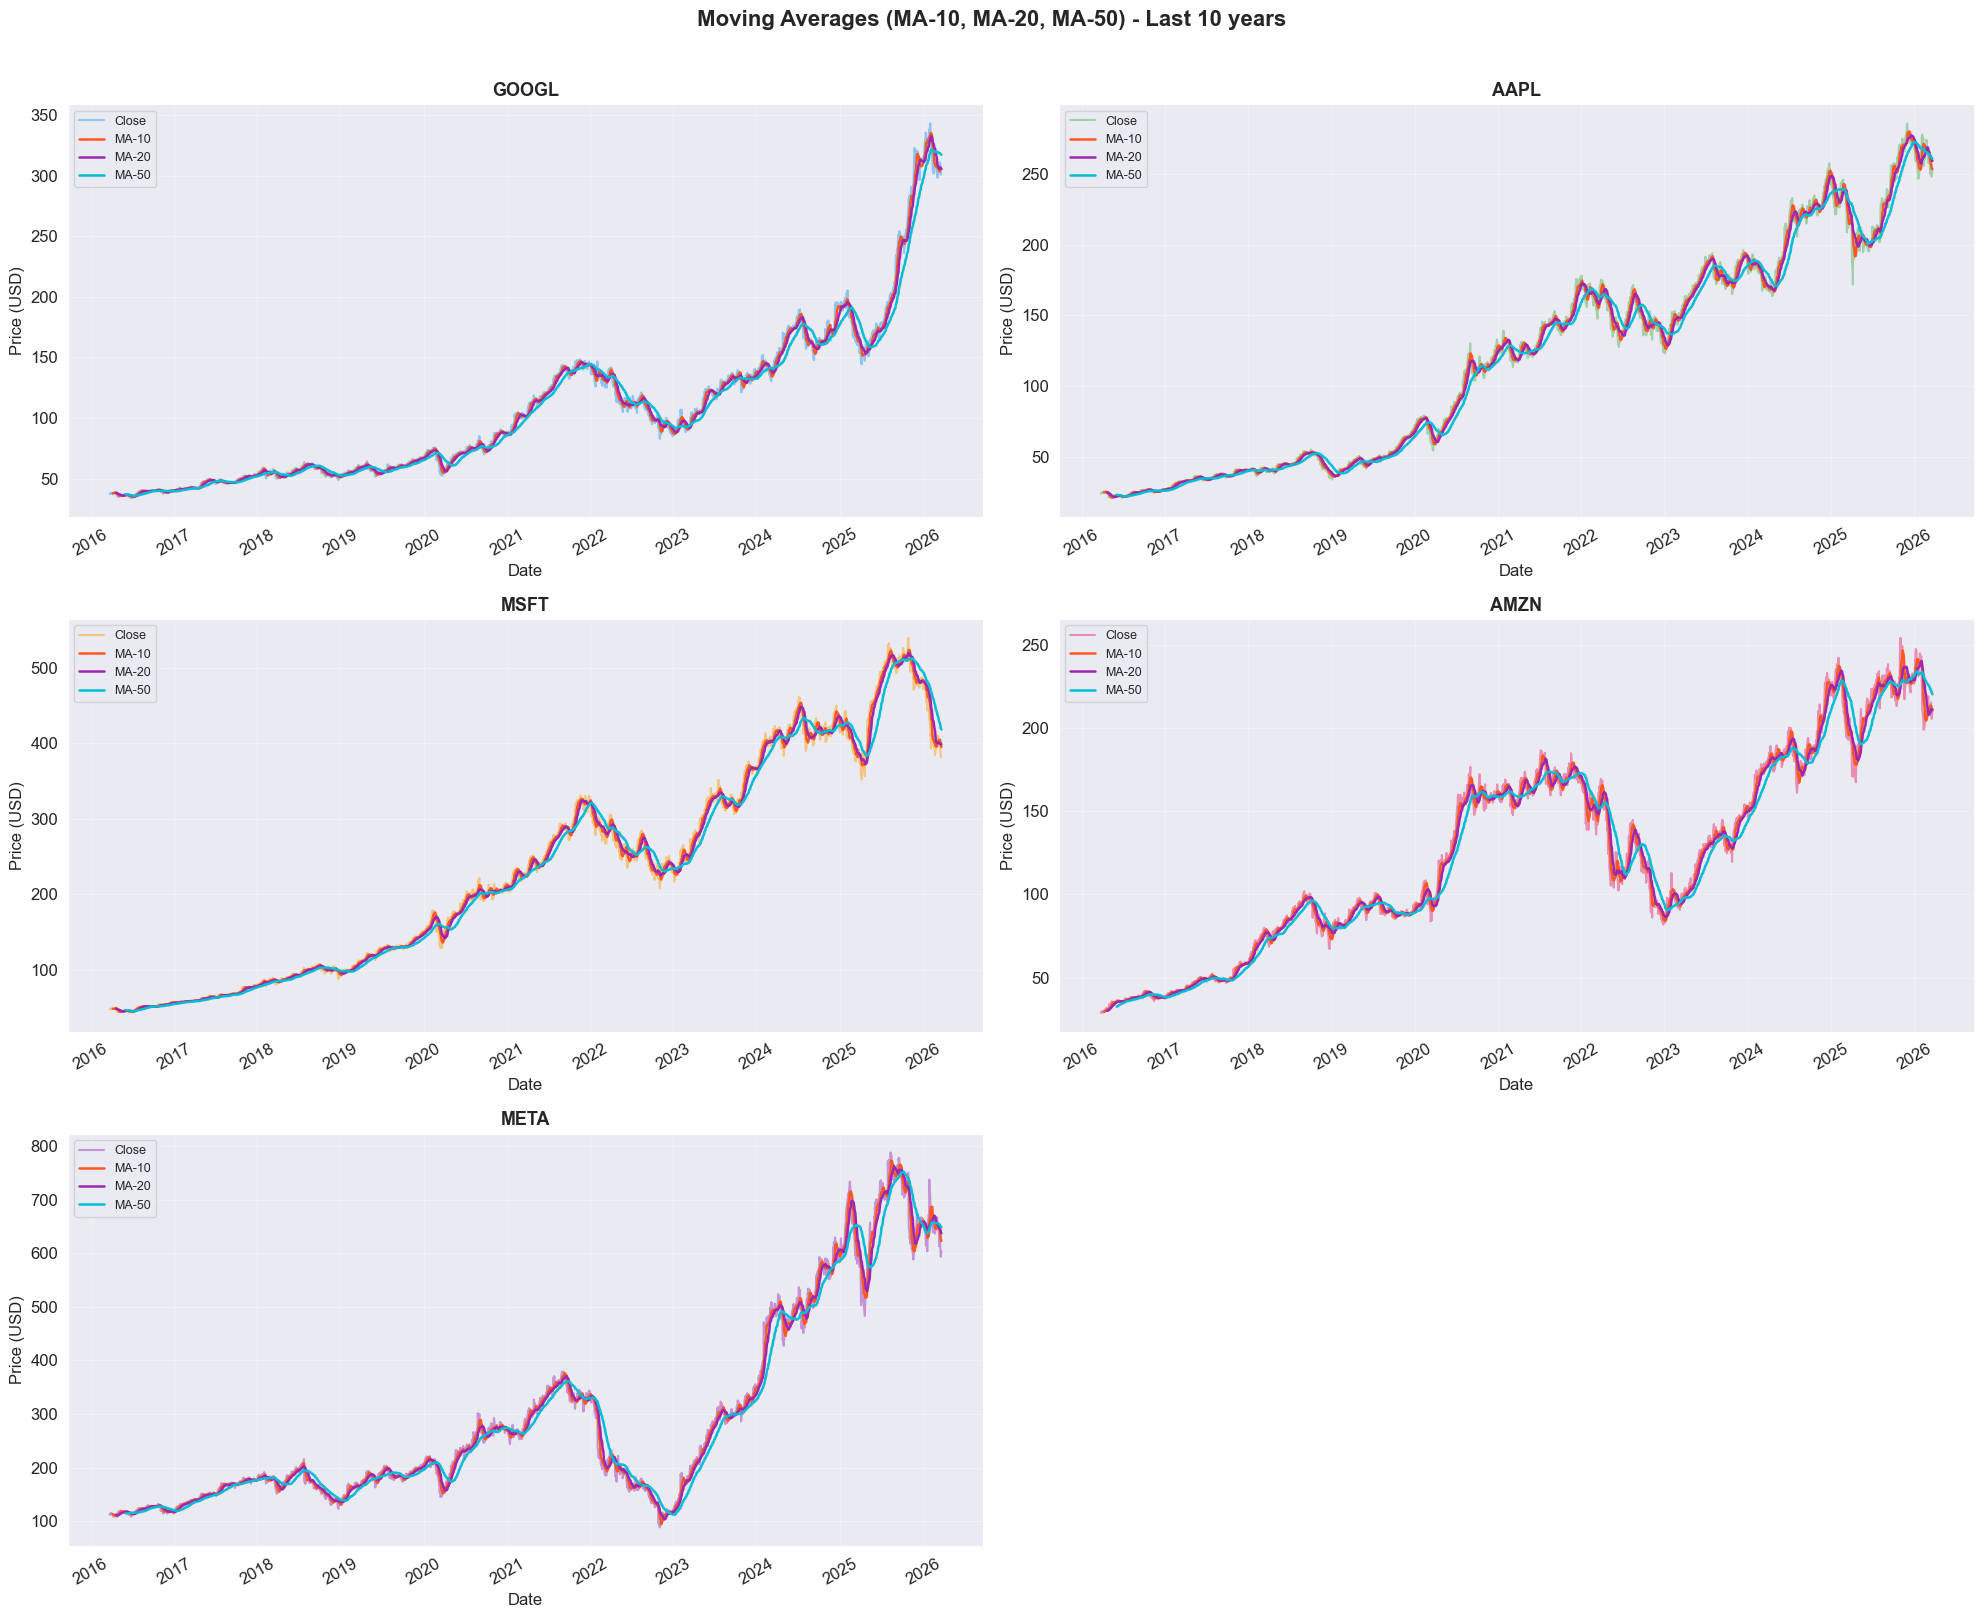

📌 MA-50 captures long-term trends; MA-10/MA-20 crossovers signal momentum shifts.


In [19]:
# -- Plot 5: Moving averages per stock --
MA_COLORS = {'MA_10': '#FF5722', 'MA_20': '#9C27B0', 'MA_50': '#00BCD4'}

fig, axes = plt.subplots(3, 2, figsize=(20, 16))
fig.suptitle('Moving Averages (MA-10, MA-20, MA-50) - Last 10 years', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, (ticker, base_color) in enumerate(zip(TICKERS, PALETTE)):
    df = frames[ticker]
    axes[i].plot(df.index, df['Close'], color=base_color, linewidth=1.5, alpha=0.45, label='Close')
    for ma, mc in MA_COLORS.items():
        axes[i].plot(df.index, df[ma], color=mc, linewidth=1.8, label=ma.replace('_', '-'))
    axes[i].set_title(ticker, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Price (USD)')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=9)
    
fig.delaxes(axes[5]) # Remove empty subplot
plt.tight_layout()
plt.savefig('moving_averages.png', dpi=300, bbox_inches='tight')
plt.show()
print('📌 MA-50 captures long-term trends; MA-10/MA-20 crossovers signal momentum shifts.')

<a id='6'></a>
### 🔗 Q4 — What was the correlation between different stocks?

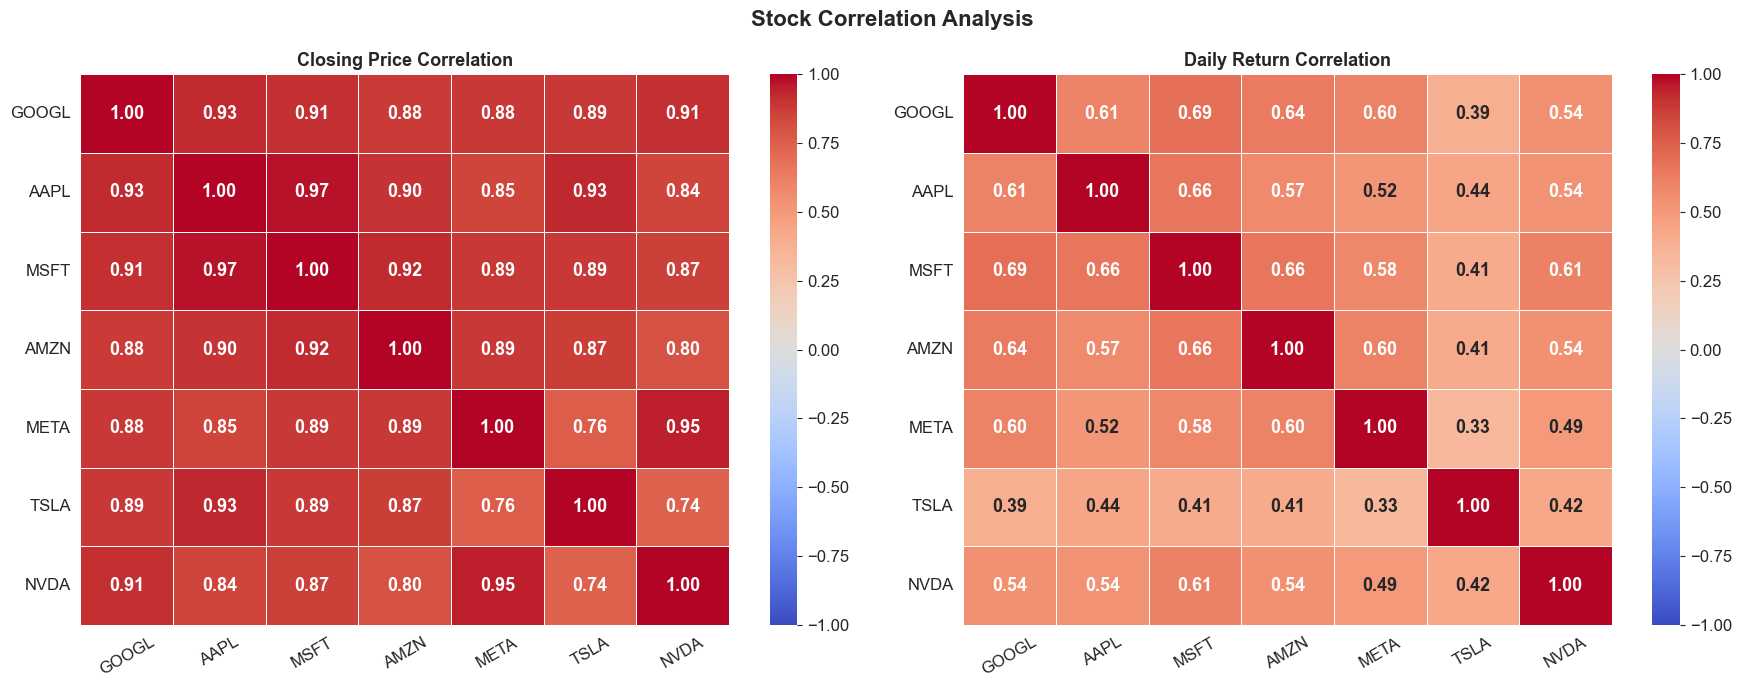

In [8]:
# -- Correlation heatmaps --
close_corr = closing_prices.corr()
return_corr = daily_returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Stock Correlation Analysis', fontsize=16, fontweight='bold')

for ax, corr_matrix, title in zip(
    axes,
    [close_corr, return_corr],
    ['Closing Price Correlation', 'Daily Return Correlation']
):
    sns.heatmap(
        corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
        center=0, vmin=-1, vmax=1, ax=ax,
        linewidths=0.5, linecolor='white',
        annot_kws={"size": 13, "weight": 'bold'}  
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)
    
plt.tight_layout()
plt.savefig('correlation_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

⏳ Generating pairplot — this may take a few seconds...


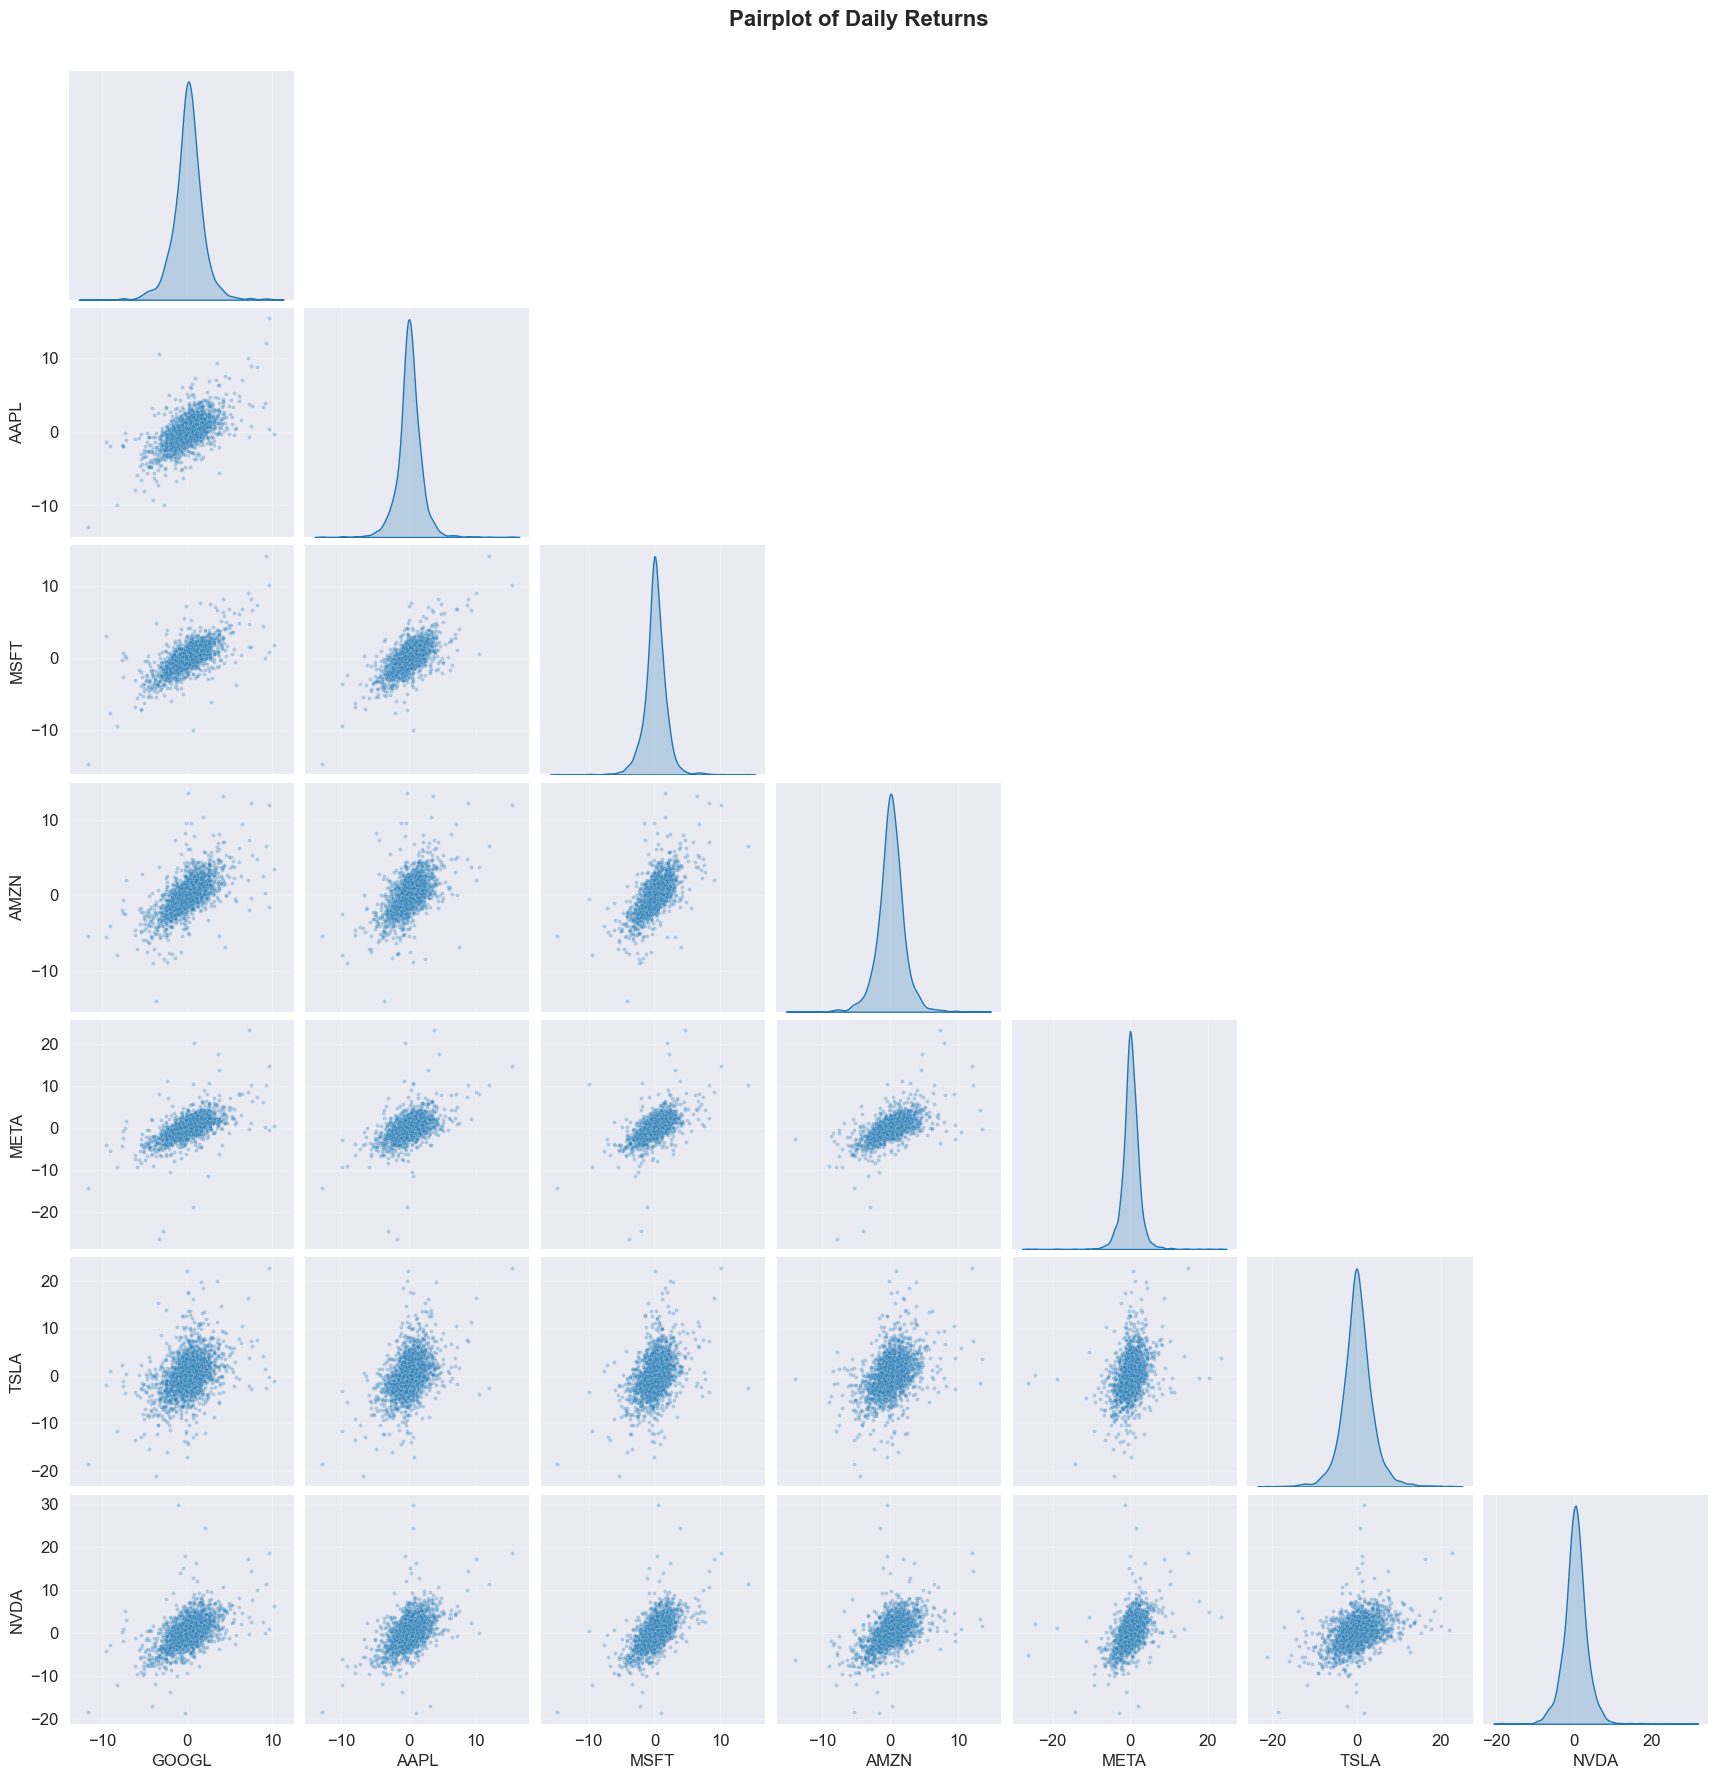


📋 Daily Return Correlation Matrix:


,GOOGL,AAPL,MSFT,AMZN,META,TSLA,NVDA
GOOGL,1.000,0.606,0.689,0.636,0.605,0.390,0.540
AAPL,0.606,1.000,0.661,0.574,0.519,0.440,0.536
MSFT,0.689,0.661,1.000,0.664,0.582,0.412,0.611
AMZN,0.636,0.574,0.664,1.000,0.602,0.409,0.539
META,0.605,0.519,0.582,0.602,1.000,0.333,0.494
TSLA,0.390,0.440,0.412,0.409,0.333,1.000,0.423
NVDA,0.540,0.536,0.611,0.539,0.494,0.423,1.000


In [9]:
# Pairplot of daily returns --
print('⏳ Generating pairplot — this may take a few seconds...')
pp = sns.pairplot(
    daily_returns.dropna(),
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 8},
    diag_kws={'fill': True},
    corner=True
)
pp.figure.suptitle('Pairplot of Daily Returns', y=1.02, fontsize=16, fontweight='bold')
plt.savefig('daily_returns_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n📋 Daily Return Correlation Matrix:')
return_corr.round(3)

<a id='7'></a>
### ⚠️ Q5 — How much value do we put at risk by investing in a particular stock?

Two approaches:
- **Historical VaR** — empirical worst-case at the chosen confidence level
- **Monte Carlo VaR** — simulated future 1-day returns via Geometric Brownian Motion

In [ ]:
# -- VaR configuration --

INVESTMENT = 10_000 # USD
CONFIDENCE = 0.95 # 95%
MC_SIMULATIONS = 10_000
TIME_HORIZON = 1 # 1 day

var_results = []

for ticker in TICKERS:
    ret =  daily_returns[ticker].dropna() / 100
    
    # Historical VaR
    hist_var = np.percentile(ret, (1 - CONFIDENCE) * 100) * INVESTMENT
    
    # Monte Carlo VaR (GBM)
    mu, sigma = ret.mean(), ret.std()
    simulated = np.random.normal(
        mu * TIME_HORIZON, 
        sigma * np.sqrt(TIME_HORIZON), 
        MC_SIMULATIONS
    )
    mc_var = np.percentile(simulated, (1 - CONFIDENCE) * 100) * INVESTMENT

    var_results.append({
        'Ticker' : ticker,
        'Daily Volatility (%)': round(sigma * 100, 4),
        'Historical VaR ($)': round(abs(hist_var), 2),
        'Monte Carlo VaR ($)': round(abs(mc_var), 2),
        'Hist VaR (%)' : round((abs(hist_var) / INVESTMENT) * 100, 2),
        'MC VaR (%)' : round((abs(mc_var) / INVESTMENT) * 100, 2)
    })
    
var_df = pd.DataFrame(var_results).set_index('Ticker')
print(f'📋 VaR Summary | Investment: ${INVESTMENT:,} | Confidence: {int(CONFIDENCE*100)}%\n')
var_df

In [ ]:
# - Plot 6: VaR bar chart --
from numpy import var


x = np.arange(len(TICKERS))
width = 0.35

fig, ax =  plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, var_df['Historical VaR ($)'], width, label='Historical VaR', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, var_df['Monte Carlo VaR ($)'], width, label='Monte Carlo VaR', color='#E91E63', alpha=0.85)

ax.bar_label(bars1, fmt='$%.0f', padding=3, fontsize=10, fontweight='bold')
ax.bar_label(bars2, fmt='$%.0f', padding=3, fontsize=10, fontweight='bold')
ax.set_title(f'Value at Risk (VaR) Comparison | Investment: ${INVESTMENT:,} | Confidence: {int(CONFIDENCE*100)}%', fontsize=14, fontweight='bold')
ax.set_ylabel('Maximum Expected Daily Loss (USD)')
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, fontsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('var_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# -- Plot7: Monte Carlo price paths for AAPL(1 trading year) --
MC_PATHS = 200
MC_DAYS = 252 # Trading days in a year

aapl_ret = daily_returns['AAPL'].dropna() / 100
mu_a = aapl_ret.mean()
sigma_a = aapl_ret.std()
last_price = frames['AAPL']['Close'].iloc[-1]

shocks = np.random.normal(mu_a, sigma_a, (MC_DAYS, MC_PATHS))
price_paths = last_price * np.exp(np.cumsum(shocks, axis=0))

plt.figure(figsize=(14, 6))
plt.plot(price_paths, alpha=0.15, linewidth=0.7, color='steelblue')
plt.plot(price_paths.mean(axis=1), color='red', linewidth=2.5, label='Mean Path')
plt.axhline(last_price, color='black', linestyle='--', linewidth=1.5,
            label=f'Current Price ${last_price:.2f}')
plt.title(f'AAPL — Monte Carlo Simulation ({MC_PATHS} paths, {MC_DAYS} trading days)',
          fontsize=14, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('Simulated Price (USD)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('q5_monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()

final_prices = price_paths[-1]
print(f'📌 AAPL after {MC_DAYS} trading days (simulated):')
print(f'   5th  percentile : ${np.percentile(final_prices,  5):.2f}')
print(f'   Mean            : ${final_prices.mean():.2f}')
print(f'   95th percentile : ${np.percentile(final_prices, 95):.2f}')
